<a href="https://colab.research.google.com/github/aldovillalbabs-gif/Telecom-Analysis/blob/main/notebooks/Project-ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
!git clone https://github.com/aldovillalbabs-gif/Telecom-Analysis.git
%cd Telecom-Analysis


Cloning into 'Telecom-Analysis'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 967.15 KiB | 13.25 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/Telecom-Analysis


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# cargar archivos
plans = pd.read_csv('data/plans.csv')
users = pd.read_csv('data/users_latam.csv')
usage = pd.read_csv('data/usage.csv')

In [5]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())     # Cantidad de valores nulos
print(usage.isna().mean())    # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Diagnóstico de valores nulos
En el dataset plans no se identifican valores nulos, por lo que no se requieren acciones de limpieza adicionales.
En el dataset users, la columna city presenta 469 valores nulos (11.7%). Debido a que el porcentaje se encuentra entre 5% y 30%, se podría investigar la causa o imputar con un valor como "Unknown" para mantener la información del registro sin eliminar filas.
La columna churn_date presenta 3534 valores nulos (88.35%). Este porcentaje alto probablemente indica que los clientes no han cancelado el servicio, por lo que los valores nulos representan usuarios activos. En este caso, no se recomienda eliminar ni imputar estos valores.
En el dataset usage, la columna date presenta 50 valores nulos (0.12%). Al ser menor al 5%, se podría imputar o eliminar esos registros sin afectar significativamente el análisis.
La columna duration tiene 22,076 valores nulos (55.19%). Este alto porcentaje sugiere que la variable no aplica para todos los registros (por ejemplo, podría corresponder solo a llamadas). Se recomienda mantener los valores nulos ya que representan ausencia de llamadas.
La columna length presenta 17,896 valores nulos (44.74%). Esto probablemente ocurre porque esta variable aplica únicamente a mensajes de texto. Por lo tanto, los valores nulos son esperados y se deben mantener.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra valores entre 10000 y 13999, lo cual es consistente con un identificador único de usuario. No se observan valores inválidos en esta variable.
- La columna `age` presenta un valor mínimo de -999, lo cual no es una edad válida. Esto indica la presencia de un sentinel value utilizado para representar datos faltantes o errores en la captura de datos. Se recomienda reemplazar este valor por NaN para tratarlo como dato faltante durante el proceso de limpieza.

In [ ]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna user_id en el dataset users muestra valores entre 10000 y 13999, lo cual es consistente con un identificador único de usuario. No se observan valores inválidos en esta columna.
- La columna age presenta un valor mínimo de -999, lo cual no es una edad válida. Este valor probablemente representa un sentinel utilizado para indicar datos faltantes. Se recomienda reemplazar este valor por NaN para tratarlo adecuadamente durante el proceso de limpieza de datos.
- En el dataset usage, las columnas id y user_id muestran rangos consistentes con identificadores únicos y no presentan valores inválidos.
- La columna duration tiene valores mínimos de 0, lo cual puede representar llamadas muy cortas o registros donde no hubo duración efectiva de llamada, por lo que no necesariamente representa un error.
- La columna length también presenta valores mínimos de 0, lo cual puede indicar mensajes sin contenido o registros donde la longitud del mensaje es mínima. No se identifican valores negativos o sentinels evidentes en estas columnas.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].value_counts())
    print()

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna city contiene varias ciudades como Bogotá, CDMX, Medellín, GDL, Cali y MTY. Sin embargo, también aparece el valor "?" en 96 registros. Este valor probablemente representa un dato faltante o desconocido, por lo que se considera un sentinel. Se recomienda reemplazar este valor por NaN o por una categoría como "Unknown" para tratarlo adecuadamente durante la limpieza de datos.
- La columna plan contiene únicamente dos categorías: Basico y Premium, lo cual coincide con los tipos de planes esperados en el dataset. No se observan valores inválidos ni inconsistencias en esta variable.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna type contiene dos categorías: text y call, que representan mensajes de texto y llamadas respectivamente. Ambas categorías son coherentes con el tipo de servicios que ofrece una empresa de telecomunicaciones. No se observan valores inesperados, errores tipográficos ni categorías adicionales, por lo que no se identifican problemas de calidad de datos en esta variable.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Durante la exploración de los datos se identificaron algunos valores inválidos o sentinels.
En la columna age del dataset users se detectó el valor -999, el cual no representa una edad válida y probablemente fue utilizado como un sentinel para indicar datos faltantes. Se recomienda reemplazar este valor por NaN para poder tratarlo adecuadamente en el análisis.
En la columna city del dataset users se encontró el valor "?", el cual probablemente representa una ciudad desconocida o un dato faltante. Se recomienda reemplazar este valor por NaN o por una categoría como "Unknown".
En el dataset usage, las columnas duration y length presentan muchos valores nulos, pero esto parece deberse a que cada variable aplica únicamente a ciertos tipos de registros (duración para llamadas y longitud para mensajes de texto). Por lo tanto, estos valores nulos no se consideran errores y se recomienda mantenerlos.
Finalmente, la columna type contiene únicamente las categorías call y text, las cuales son coherentes con el tipo de servicio analizado, por lo que no se identificaron valores inválidos en esta variable.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se convirtió el formato de fecha utilizando pd.to_datetime() para asegurar un formato adecuado y evitar errores de conversión.
Al revisar los años presentes en esta columna se observaron registros correspondientes a 2022, 2023 y 2024, los cuales se encuentran dentro del rango esperado del dataset. Sin embargo, también se identificaron 40 registros con el año 2026, lo cual representa una fecha fuera de rango, ya que el dataset solo contiene información hasta el año 2024.
Estos valores probablemente corresponden a errores de captura de datos, por lo que se recomienda revisarlos o reemplazarlos por NaN para evitar que afecten el análisis.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, se convirtió al formato de fecha utilizando pd.to_datetime() para asegurar consistencia en el tipo de dato.
Al analizar los años presentes en esta columna se observó que todos los registros corresponden al año 2024, lo cual coincide con el periodo de datos indicado para el análisis. No se identificaron fechas fuera de rango, años futuros ni valores inconsistentes, por lo que no se requieren acciones adicionales de limpieza para esta variable.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

- Al revisar los años presentes en las columnas de fecha se identificó que la columna reg_date del dataset users contiene registros correspondientes a los años 2022, 2023 y 2024, los cuales se encuentran dentro del rango esperado. Sin embargo, también aparecen 40 registros con el año 2026, lo cual representa una fecha fuera de rango, ya que el dataset solo contiene información hasta el año 2024. Estos registros probablemente corresponden a errores de captura de datos, por lo que se recomienda reemplazar estas fechas por valores nulos (NaT) o revisarlas antes del análisis para evitar sesgos en los resultados.
Por otro lado, en la columna date del dataset usage se observó que todos los registros corresponden al año 2024, lo cual es consistente con el periodo de datos indicado. No se detectaron años imposibles ni inconsistencias en esta columna, por lo que no se requiere ninguna acción adicional.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se analizó la presencia de valores nulos en las columnas duration y length en relación con la variable type. Los resultados muestran que los valores nulos en duration aparecen casi exclusivamente cuando el tipo de registro es text, lo cual es consistente ya que la duración solo aplica a llamadas. De forma similar, los valores nulos en length aparecen principalmente cuando el tipo es call, ya que la longitud del mensaje solo aplica a mensajes de texto.
Esto confirma que los valores faltantes dependen de otra variable del dataset (type), por lo que se consideran MAR (Missing At Random). En consecuencia, estos valores nulos no se imputan ni se eliminan, ya que representan correctamente la estructura de los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
  
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.
**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

- Se realizó un resumen estadístico de las variables numéricas age, cant_mensajes, cant_llamadas y cant_minutos_llamada para comprender el comportamiento de uso de los usuarios.
La edad de los usuarios presenta un rango entre 18 y 79 años, con una mediana de 48 años, lo que indica una distribución relativamente amplia de edades dentro de la base de clientes.
En cuanto al comportamiento de uso, los usuarios envían en promedio 5.52 mensajes y realizan aproximadamente 4.48 llamadas. La mediana muestra valores cercanos a estos promedios (5 mensajes y 4 llamadas), lo que sugiere una distribución relativamente equilibrada sin grandes asimetrías.
Respecto a los minutos de llamadas, el promedio es de 23.3 minutos, con un máximo de 155.7 minutos, lo que podría indicar la presencia de algunos usuarios con uso intensivo del servicio.
Finalmente, se analizó la distribución del tipo de plan. Se observó que 64.88% de los usuarios utilizan el plan Básico, mientras que 35.12% utilizan el plan Premium, lo que indica que la mayoría de los clientes se encuentran en el plan básico.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas.

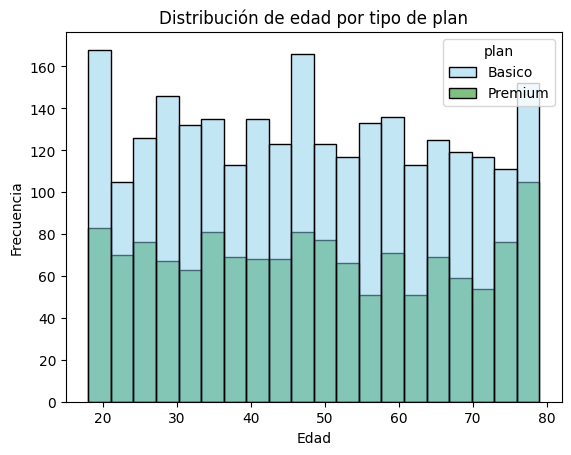

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=['skyblue','green'],
    bins=20
)

plt.title("Distribución de edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: No se observan diferencias claras en la distribución de edades entre los usuarios del plan Básico y Premium. Ambos planes presentan usuarios a lo largo de todo el rango de edad (18 a 79 años), lo que sugiere que la edad no parece influir significativamente en la elección del tipo de plan.

📊 Tipo de distribución:
La variable age presenta una distribución relativamente simétrica, con usuarios distribuidos de forma bastante uniforme a lo largo de los rangos de edad.

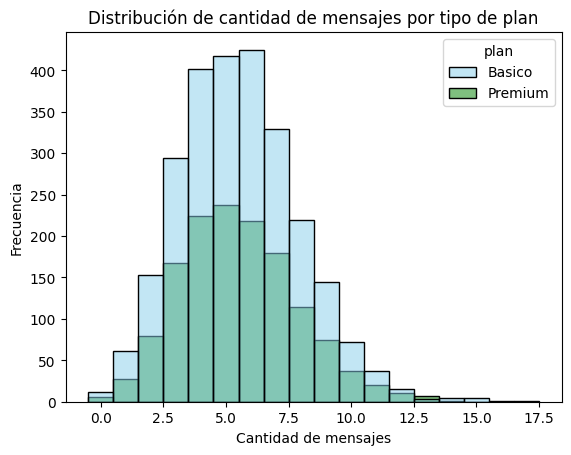

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=['skyblue','green'],
    bins=range(0, 20),
    discrete=True
)

plt.title("Distribución de cantidad de mensajes por tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡 Insight:
Los usuarios de los planes Básico y Premium muestran un comportamiento muy similar en la cantidad de mensajes enviados. La mayoría de los usuarios se concentra aproximadamente entre 3 y 7 mensajes, y no se observa una diferencia marcada entre ambos planes, ya que las distribuciones se superponen en casi todo el rango.

📊 Tipo de distribución:
La variable cant_mensajes presenta una distribución ligeramente sesgada a la derecha, lo que indica que la mayoría de los usuarios envía una cantidad moderada de mensajes, mientras que un grupo pequeño envía cantidades más altas.

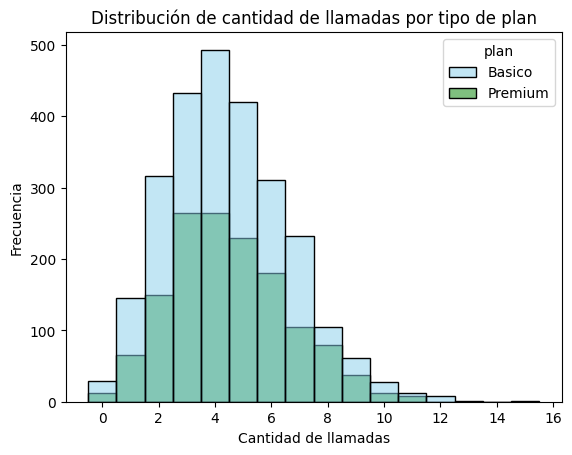

In [ ]:
# Histograma para visualizar la cantidad de llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=['skyblue','green'],
    bins=range(0, 20),   # bins enteros
    discrete=True
)

plt.title("Distribución de cantidad de llamadas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡 Insight:
Los usuarios de los planes Básico y Premium presentan un comportamiento muy similar en la cantidad de llamadas realizadas. La mayor concentración de usuarios se encuentra aproximadamente entre 3 y 6 llamadas, y las distribuciones de ambos planes se superponen en la mayoría de los rangos. Esto sugiere que no existe una diferencia clara en el número de llamadas entre los dos tipos de plan.

📊 Tipo de distribución:
La variable cant_llamadas presenta una distribución ligeramente sesgada a la derecha, lo que indica que la mayoría de los usuarios realiza pocas llamadas, mientras que un grupo más pequeño realiza una mayor cantidad de llamadas (valores más altos hacia la derecha del gráfico).

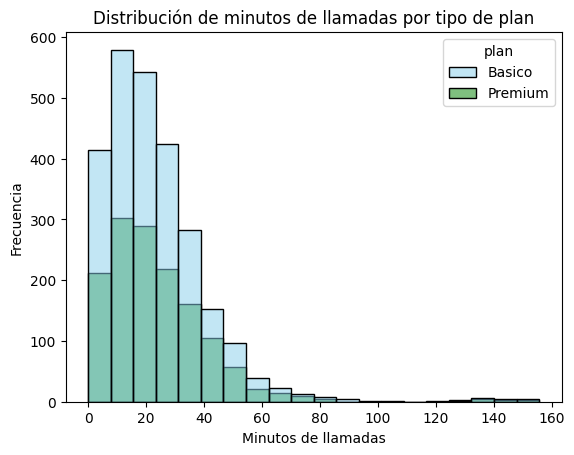

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
# Histograma para visualizar los minutos de llamadas
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=['skyblue','green'],
    bins=20
)

plt.title("Distribución de minutos de llamadas por tipo de plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡 Insight:
Se observa que tanto los usuarios del plan Básico como del plan Premium concentran la mayor parte de su consumo entre aproximadamente 5 y 30 minutos de llamadas. Sin embargo, en los rangos más altos de minutos se aprecia una ligera presencia de usuarios Premium, lo que podría indicar que algunos usuarios de este plan tienden a consumir más minutos. También se observan algunos valores extremos (usuarios con más de 100 minutos), lo que sugiere la existencia de usuarios intensivos.

📊 Tipo de distribución:
La variable cant_minutos_llamada presenta una distribución fuertemente sesgada a la derecha, donde la mayoría de los usuarios tiene un consumo bajo o moderado de minutos, mientras que un pequeño grupo presenta consumos mucho más altos, generando una cola larga hacia la derecha del histograma.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

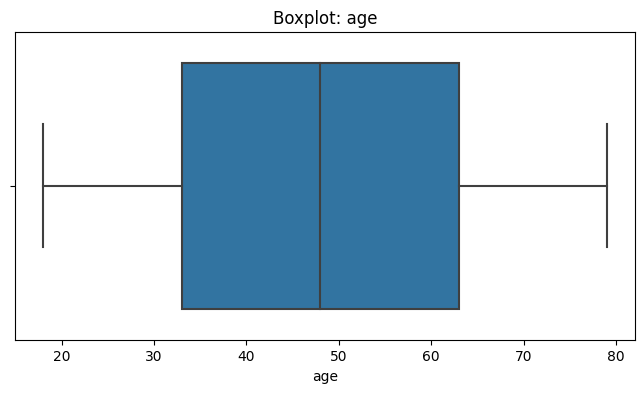

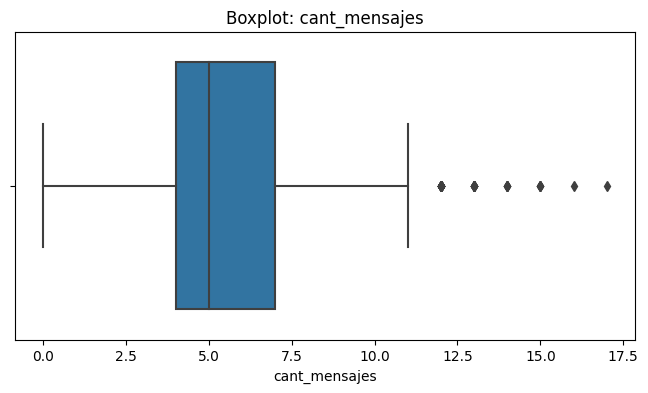

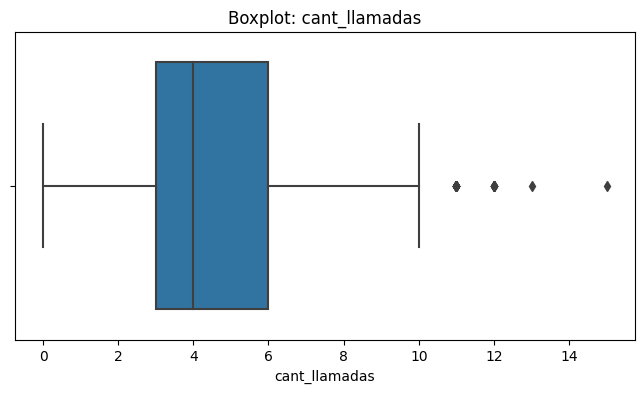

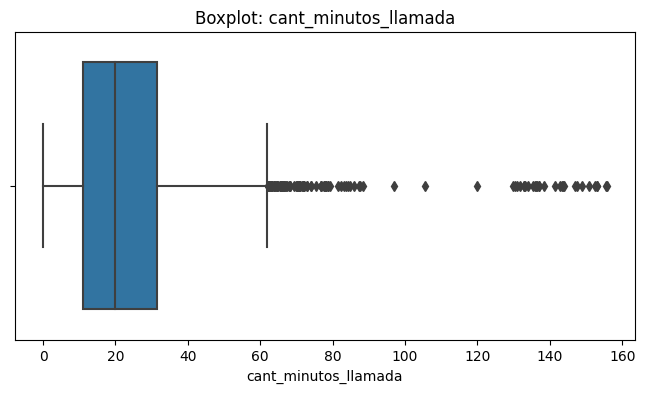

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡 Insights
- Age: No presenta outliers. Los valores se encuentran dentro de un rango razonable entre aproximadamente 18 y 79 años, por lo que no se observan edades extremas o inconsistentes.
- cant_mensajes: Sí presenta algunos outliers superiores (usuarios que envían muchos más mensajes que el promedio, aproximadamente arriba de 11-12 mensajes). Estos valores probablemente representan usuarios con mayor actividad, no errores de datos.
- cant_llamadas: También presenta outliers en el extremo superior (alrededor de 10 llamadas o más). Esto indica que existen usuarios que realizan más llamadas que el resto, pero es un comportamiento posible dentro del uso normal del servicio.
- cant_minutos_llamada: Presenta varios outliers superiores, especialmente por encima de aproximadamente 60 minutos. Esto indica que algunos usuarios tienen un consumo de minutos significativamente mayor que el promedio.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'\nColumna: {col}')
    print(f'Límite superior: {limite_superior}')

    outliers = user_profile[user_profile[col] > limite_superior]
    print(f'Cantidad de outliers: {len(outliers)}')



Columna: cant_mensajes
Límite superior: 11.5
Cantidad de outliers: 46

Columna: cant_llamadas
Límite superior: 10.5
Cantidad de outliers: 30

Columna: cant_minutos_llamada
Límite superior: 61.8575
Cantidad de outliers: 109


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡 Insights
- cant_mensajes: Se detectan outliers por encima del límite superior (11.5), con un máximo de 17 mensajes. Estos valores pueden representar usuarios con mayor actividad, por lo que se decide mantenerlos.
- cant_llamadas: Existen outliers por encima del límite superior (10.5), con un máximo de 15 llamadas. Estos valores son plausibles dentro del comportamiento real de uso, por lo que se mantienen.
- cant_minutos_llamada: Se observan varios outliers por encima del límite superior (61.86), con un máximo de 155.69 minutos. Esto puede corresponder a usuarios con uso intensivo del servicio, por lo que no se eliminan.

---

## 🧩Paso 6: Segmentación de Clientes

### 7.1 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos



In [ ]:
# Crear columna grupo_uso
# Crear columna grupo_uso

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor



### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


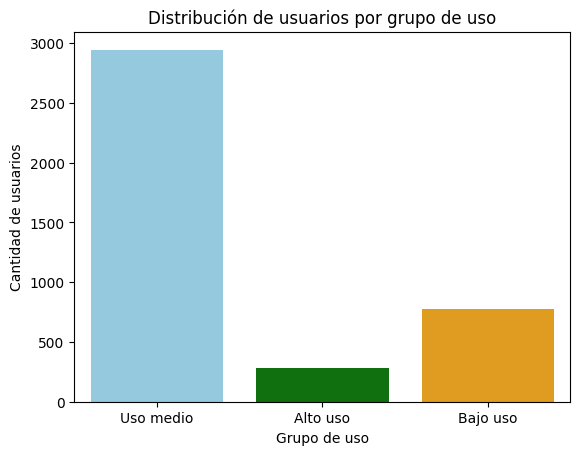

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue','green','orange'])

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

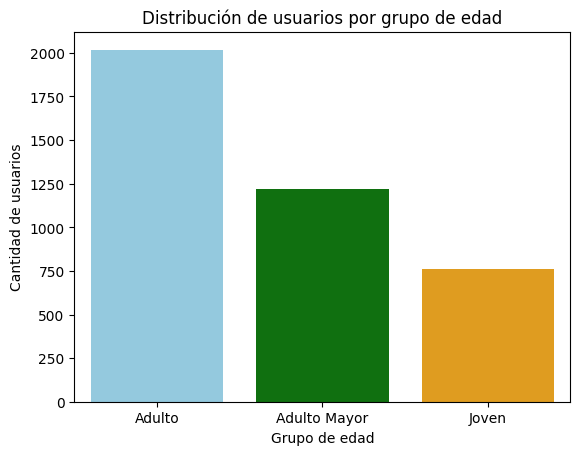

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green','orange'])

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la columna age se detectó el valor sentinel -999, utilizado para representar datos faltantes. Este valor fue reemplazado por la mediana de la edad, evitando distorsionar la distribución.
- En la columna city se identificó el valor "?", el cual representa información desconocida. Este valor fue convertido a NA para tratarlo correctamente como dato faltante.
- En la columna reg_date se detectaron 40 registros con año 2026, lo cual es un valor fuera de rango considerando que el dataset contiene datos hasta 2024. Estas fechas se marcaron como NA.
- Se detectaron valores extremos (outliers) en las variables de uso (mensajes, llamadas y minutos de llamadas). Sin embargo, estos valores se mantuvieron ya que representan usuarios con alto nivel de actividad, lo cual es un comportamiento válido para el negocio.


🔍 **Segmentos por Edad**
- Jóvenes (<30 años): representan el grupo más pequeño de usuarios.
- Adultos (30-59 años): constituyen el segmento más grande de clientes dentro de la base de usuarios.
- Adultos mayores (60+ años): representan una proporción relevante del total de usuarios.
- *Esto indica que la base de clientes de ConnectaTel está compuesta principalmente por usuarios adultos, lo que puede influir en las estrategias de marketing y diseño de productos.*


📊 **Segmentos por Nivel de Uso**
Se identificaron tres niveles de uso del servicio:
- Bajo uso: usuarios con pocas llamadas y mensajes.
- Uso medio: representa la mayoría de los clientes, indicando un patrón de uso moderado del servicio.
- Alto uso: grupo más pequeño, pero con un consumo significativamente mayor de llamadas y mensajes.
➡️ Esto sugiere que la mayoría de los clientes tienen un consumo moderado, mientras que existe un grupo pequeño de usuarios intensivos que consumen más recursos del servicio.

📈 **Patrones de uso extremo (outliers)**
Se identificaron usuarios con niveles de actividad considerablemente mayores al promedio:
- Hasta 17 mensajes.
- Hasta 15 llamadas.
- Hasta 155 minutos de llamadas.

Estos usuarios representan clientes intensivos, que podrían ser particularmente valiosos para la empresa si cuentan con planes adecuados para su nivel de consumo.

💡 **Recomendaciones**
- Diseñar planes diferenciados según nivel de uso, especialmente para usuarios de alto consumo, quienes podrían beneficiarse de planes premium con mayor capacidad de llamadas y mensajes.
- Optimizar la oferta para el segmento mayoritario (uso medio), ya que este grupo representa la mayor parte de los clientes y podría responder positivamente a planes balanceados en costo y beneficios.
- Crear estrategias específicas para usuarios adultos, que constituyen la mayor proporción de la base de clientes.
- Analizar a los usuarios intensivos para identificar oportunidades de planes ilimitados o paquetes premium, lo cual podría aumentar los ingresos por cliente.


---


## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.

---

Link a repositorio público del proyecto: `LINK a tu repo aquí`